In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATASET_PATH = "../data/train.csv"

## Read dataset

In [3]:
ds = pd.read_csv(DATASET_PATH)

In [4]:
print('columns count - ',len(ds.columns), '\n')
print('columns: ',list(ds.columns))
print('Samples count: ',ds.shape[0])
display(ds.head(5))

columns count -  24 

columns:  ['Type', 'Name', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'Quantity', 'Fee', 'State', 'RescuerID', 'VideoAmt', 'Description', 'PetID', 'PhotoAmt', 'AdoptionSpeed']
Samples count:  14993


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


## Types of data

In [5]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14993 entries, 0 to 14992
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Type           14993 non-null  int64  
 1   Name           13728 non-null  object 
 2   Age            14993 non-null  int64  
 3   Breed1         14993 non-null  int64  
 4   Breed2         14993 non-null  int64  
 5   Gender         14993 non-null  int64  
 6   Color1         14993 non-null  int64  
 7   Color2         14993 non-null  int64  
 8   Color3         14993 non-null  int64  
 9   MaturitySize   14993 non-null  int64  
 10  FurLength      14993 non-null  int64  
 11  Vaccinated     14993 non-null  int64  
 12  Dewormed       14993 non-null  int64  
 13  Sterilized     14993 non-null  int64  
 14  Health         14993 non-null  int64  
 15  Quantity       14993 non-null  int64  
 16  Fee            14993 non-null  int64  
 17  State          14993 non-null  int64  
 18  Rescue

## Check missing data

In [6]:
print("Any missing sample in training set:",ds.isnull().values.any())

Any missing sample in training set: True


In [7]:
for col in ds.columns:
    if ds[col].isnull().values.any():
        print("Missing data in ", col)

Missing data in  Name
Missing data in  Description


In [8]:
missing = list()
for x in ds.columns:
    if ds[x].isnull().sum() != 0:
        print(f"{x:<30}{ds[x].isnull().sum():<10}{(ds[x].isnull().sum() / ds.shape[0])*100}%")
        missing.append(x)

Name                          1265      8.437270726338959%
Description                   13        0.0867071299939972%


## Unique values count

In [9]:
ds.nunique()

Type                 2
Name              9059
Age                106
Breed1             176
Breed2             135
Gender               3
Color1               7
Color2               7
Color3               6
MaturitySize         4
FurLength            3
Vaccinated           3
Dewormed             3
Sterilized           3
Health               3
Quantity            19
Fee                 74
State               14
RescuerID         5595
VideoAmt             9
Description      14031
PetID            14993
PhotoAmt            31
AdoptionSpeed        5
dtype: int64

## Distribution statistics

In [10]:
ds.describe()

,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,VideoAmt,PhotoAmt,AdoptionSpeed
count,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000
mean,1.457614,10.452078,265.272594,74.009738,1.776162,2.234176,3.222837,1.882012,1.862002,1.467485,1.731208,1.558727,1.914227,1.036617,1.576069,21.259988,41346.028347,0.056760,3.889215,2.516441
std,0.498217,18.155790,60.056818,123.011575,0.681592,1.745225,2.742562,2.984086,0.547959,0.599070,0.667649,0.695817,0.566172,0.199535,1.472477,78.414548,32.444153,0.346185,3.487810,1.177265
min,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,41324.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,265.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,0.000000,41326.000000,0.000000,2.000000,2.000000
50%,1.000000,3.000000,266.000000,0.000000,2.000000,2.000000,2.000000,0.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,0.000000,41326.000000,0.000000,3.000000,2.000000
75%,2.000000,12.000000,307.000000,179.000000,2.000000,3.000000,6.000000,5.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,0.000000,41401.000000,0.000000,5.000000,4.000000
max,2.000000,255.000000,307.000000,307.000000,3.000000,7.000000,7.000000,7.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,20.000000,3000.000000,41415.000000,8.000000,30.000000,4.000000


## Correlation analysis

In [11]:
important_df =  ds[['Age', 'Breed1', 'Breed2',
                    'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'Vaccinated',
                    'FurLength', 'Dewormed', 'Sterilized', 'Health',
                    'Quantity', 'Fee', 'State', 'AdoptionSpeed']]

In [12]:
important_df.head(5)

,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,Vaccinated,FurLength,Dewormed,Sterilized,Health,Quantity,Fee,State,AdoptionSpeed
0,3,299,0,1,1,7,0,1,2,1,2,2,1,1,100,41326,2
1,1,265,0,1,1,2,0,2,3,2,3,3,1,1,0,41401,0
2,1,307,0,1,2,7,0,2,1,2,1,2,1,1,0,41326,3
3,4,307,0,2,1,2,0,2,1,1,1,2,1,1,150,41401,2
4,1,307,0,1,1,0,0,2,2,1,2,2,1,1,0,41326,2


In [13]:
important_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14993 entries, 0 to 14992
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age            14993 non-null  int64
 1   Breed1         14993 non-null  int64
 2   Breed2         14993 non-null  int64
 3   Gender         14993 non-null  int64
 4   Color1         14993 non-null  int64
 5   Color2         14993 non-null  int64
 6   Color3         14993 non-null  int64
 7   MaturitySize   14993 non-null  int64
 8   Vaccinated     14993 non-null  int64
 9   FurLength      14993 non-null  int64
 10  Dewormed       14993 non-null  int64
 11  Sterilized     14993 non-null  int64
 12  Health         14993 non-null  int64
 13  Quantity       14993 non-null  int64
 14  Fee            14993 non-null  int64
 15  State          14993 non-null  int64
 16  AdoptionSpeed  14993 non-null  int64
dtypes: int64(17)
memory usage: 1.9 MB


In [14]:
corr_matrix = important_df.corr()
print(corr_matrix['AdoptionSpeed'].sort_values(ascending=False))

AdoptionSpeed    1.000000
Breed1           0.107834
Age              0.100510
Quantity         0.062931
Gender           0.057622
MaturitySize     0.045653
Health           0.029382
State            0.013119
Fee             -0.004017
Color3          -0.007014
Dewormed        -0.013210
Breed2          -0.018642
Color2          -0.038579
Color1          -0.044192
Vaccinated      -0.059043
Sterilized      -0.083447
FurLength       -0.091337
Name: AdoptionSpeed, dtype: float64


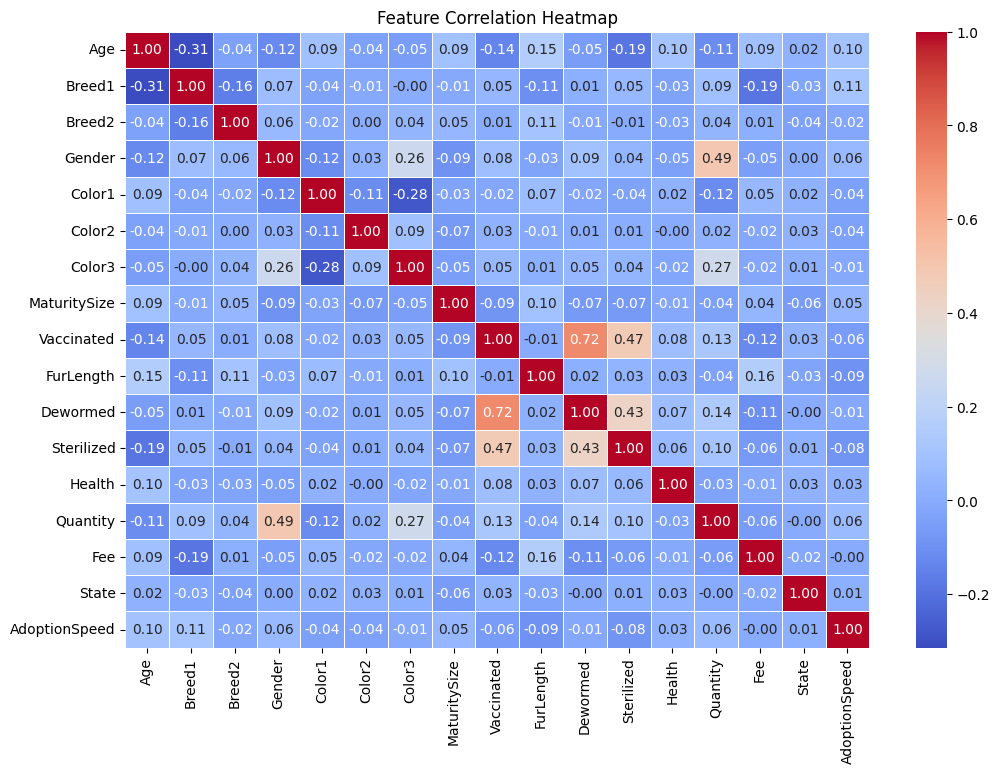

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [16]:
important_df = important_df.drop(columns=['Color3', 'Fee', 'State'])

In [17]:
important_df.head(5)

,Age,Breed1,Breed2,Gender,Color1,Color2,MaturitySize,Vaccinated,FurLength,Dewormed,Sterilized,Health,Quantity,AdoptionSpeed
0,3,299,0,1,1,7,1,2,1,2,2,1,1,2
1,1,265,0,1,1,2,2,3,2,3,3,1,1,0
2,1,307,0,1,2,7,2,1,2,1,2,1,1,3
3,4,307,0,2,1,2,2,1,1,1,2,1,1,2
4,1,307,0,1,1,0,2,2,1,2,2,1,1,2
